# Day 10: Exploratory Data Analysis & Data Cleaning Assessment

## Objective
The goal of this notebook is to inspect, clean, analyze, and prepare the dataset for Machine Learning model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("raw_dataset.csv")
df.head()

,Index,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,74,USD,139,8619793560985,Orchid,Medium,backorder,38
1,2,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,510,USD,351,3057216124300,MediumSeaGreen,Small,backorder,27
2,3,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,254,USD,409,9825254410556,Lavender,XXL,pre_order,2
3,4,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,69,USD,119,9490814777808,Pink,XL,in_stock,94
4,5,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,525,USD,727,4726650403799,LightCoral,XL,in_stock,95


---
# Phase 1: Data Inspection

In [3]:
df.shape

(1000, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Index         1000 non-null   int64
 1   Name          1000 non-null   str  
 2   Description   1000 non-null   str  
 3   Brand         1000 non-null   str  
 4   Category      1000 non-null   str  
 5   Price         1000 non-null   int64
 6   Currency      1000 non-null   str  
 7   Stock         1000 non-null   int64
 8   EAN           1000 non-null   int64
 9   Color         1000 non-null   str  
 10  Size          1000 non-null   str  
 11  Availability  1000 non-null   str  
 12  Internal ID   1000 non-null   int64
dtypes: int64(5), str(8)
memory usage: 101.7 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,1000.0,5.005000e+02,2.888194e+02,1.0,2.507500e+02,5.005000e+02,7.502500e+02,1.000000e+03
Price,1000.0,5.065490e+02,2.837736e+02,1.0,2.847500e+02,4.975000e+02,7.572500e+02,9.990000e+02
Stock,1000.0,5.017820e+02,2.921513e+02,2.0,2.430000e+02,5.040000e+02,7.502500e+02,9.990000e+02
EAN,1000.0,5.130255e+12,2.907413e+12,484264721.0,2.699217e+12,5.118167e+12,7.653439e+12,9.994627e+12
Internal ID,1000.0,4.769000e+01,2.898420e+01,1.0,2.200000e+01,4.600000e+01,7.400000e+01,9.900000e+01


In [6]:
df.isnull().sum()

Index           0
Name            0
Description     0
Brand           0
Category        0
Price           0
Currency        0
Stock           0
EAN             0
Color           0
Size            0
Availability    0
Internal ID     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Structural Diagnosis

From the initial inspection, we checked:
- **Dataset shape**: 1000 rows and 13 columns.
- **Data types**: 5 numeric columns (Index, Price, Stock, EAN, Internal ID) and 8 object/string columns.
- **Missing values**: No null values found in any column.
- **Duplicate rows**: No exact duplicate rows detected.
- **Numeric columns stored as object**: All numeric columns are correctly stored as `int64`. No corrupted text values found in numeric slots.

Additional observations:
- The `Currency` column has only one unique value (`USD`), making it a zero-variance feature.
- The `Description` column contains auto-generated filler text with no analytical value.
- The `Size` column mixes categorical labels (S, M, L, XL) with dimensional formats (8x10 in, 50x70 cm).
- The `EAN` column is a barcode identifier stored as int64 — it should not be used in arithmetic operations.

---
# Phase 2: Data Cleaning

## Step 1: Remove Duplicates
Duplicates must be removed before computing any summary statistics to avoid inflating counts and biasing averages.

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

Duplicate rows found: 0


In [9]:
df = df.drop_duplicates()
print(f"Duplicates after removal: {df.duplicated().sum()}")
print(f"Shape after deduplication: {df.shape}")

Duplicates after removal: 0
Shape after deduplication: (1000, 13)


## Step 2: Check Object Columns & Fix Data Types
We inspect all object-type columns to identify any that should be numeric but contain corrupted text values.

In [10]:
df.select_dtypes(include="object").head()

,Name,Description,Brand,Category,Currency,Color,Size,Availability
0,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,USD,Orchid,Medium,backorder
1,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,USD,MediumSeaGreen,Small,backorder
2,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,USD,Lavender,XXL,pre_order
3,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,USD,Pink,XL,in_stock
4,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,USD,LightCoral,XL,in_stock


In [11]:
# Apply pd.to_numeric to ensure Price, Stock, and Internal ID are clean numeric values.
# errors='coerce' converts any rogue text to NaN so we can handle it explicitly.

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Stock"] = pd.to_numeric(df["Stock"], errors="coerce")
df["Internal ID"] = pd.to_numeric(df["Internal ID"], errors="coerce")

print("Data types after coercion:")
print(df[["Price", "Stock", "Internal ID"]].dtypes)

Data types after coercion:
Price          int64
Stock          int64
Internal ID    int64
dtype: object


## Step 3: Drop Non-Useful Columns
- `Currency` is a zero-variance column (100% USD) — provides no information for ML.
- `Description` contains auto-generated filler text — not useful for numeric ML models.

In [12]:
print(f"Currency unique values: {df['Currency'].nunique()} -> {df['Currency'].unique().tolist()}")

df = df.drop(columns=["Currency", "Description"])

print(f"Shape after dropping columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Currency unique values: 1 -> ['USD']
Shape after dropping columns: (1000, 11)
Remaining columns: ['Index', 'Name', 'Brand', 'Category', 'Price', 'Stock', 'EAN', 'Color', 'Size', 'Availability', 'Internal ID']


## Step 4: Handle Missing Values

### Missing values BEFORE cleaning

In [13]:
print("=== Missing Values BEFORE Cleaning ===")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

=== Missing Values BEFORE Cleaning ===
Index           0
Name            0
Brand           0
Category        0
Price           0
Stock           0
EAN             0
Color           0
Size            0
Availability    0
Internal ID     0
dtype: int64

Total nulls: 0


In [14]:
# Fill missing NUMERIC values based on skewness
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        skew_val = df[col].skew()
        if abs(skew_val) > 1:
            fill_val = df[col].median()
            strategy = f"Median ({fill_val:.2f}) — distribution is highly skewed (skew={skew_val:.2f})"
            df[col] = df[col].fillna(fill_val)
        else:
            fill_val = df[col].mean()
            strategy = f"Mean ({fill_val:.2f}) — distribution is approximately symmetric (skew={skew_val:.2f})"
            df[col] = df[col].fillna(fill_val)
        print(f"  {col}: Filled with {strategy}")

print("Numeric imputation complete.")

Numeric imputation complete.


In [15]:
# Fill missing CATEGORICAL values with Mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  {col}: Filled with Mode = '{mode_val}'")

print("Categorical imputation complete.")

Categorical imputation complete.


### Missing values AFTER cleaning

In [16]:
print("=== Missing Values AFTER Cleaning ===")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

=== Missing Values AFTER Cleaning ===
Index           0
Name            0
Brand           0
Category        0
Price           0
Stock           0
EAN             0
Color           0
Size            0
Availability    0
Internal ID     0
dtype: int64

Total nulls: 0


## Missing Value Strategy

For numeric columns:
- **Median** was used when the data was highly skewed (|skewness| > 1).
- **Mean** was used when the distribution was approximately balanced (|skewness| <= 1).

For categorical columns:
- **Mode** was used because it represents the most frequent valid category.

In this dataset, all columns were already clean after type coercion — `pd.to_numeric(errors='coerce')` did not produce any new NaN values, confirming the raw data had no rogue text in numeric fields. The imputation logic above is in place as a defensive pipeline for production use.

---
# Phase 3: Visual & Statistical Analysis

## Skewness

In [17]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Skewness of numeric columns:")
print(df[numeric_cols].skew())

Skewness of numeric columns:
Index          0.000000
Price          0.035984
Stock          0.013722
EAN           -0.033969
Internal ID    0.088319
dtype: float64


**Observation:**
All numeric features have skewness values very close to 0 (|skew| < 0.1), indicating approximately symmetric distributions. This means the mean is a reliable central tendency measure, and no log or power transformations are required.

## Histograms / KDE Plots (Univariate Exploration)

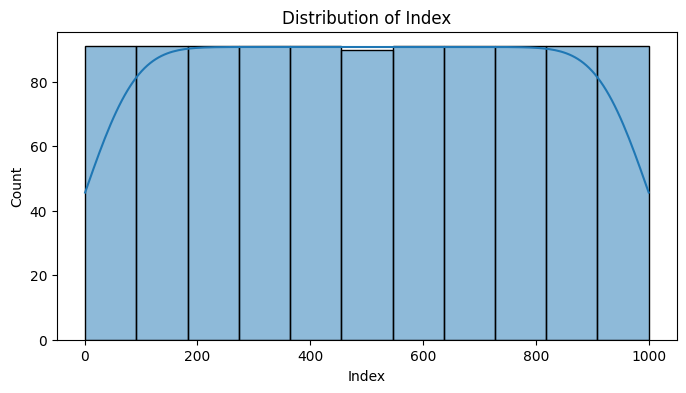

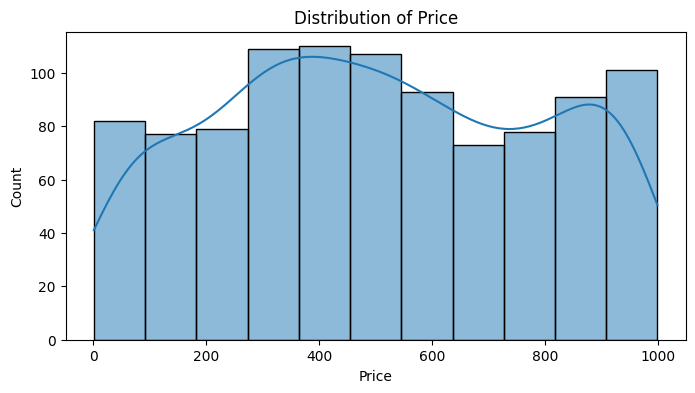

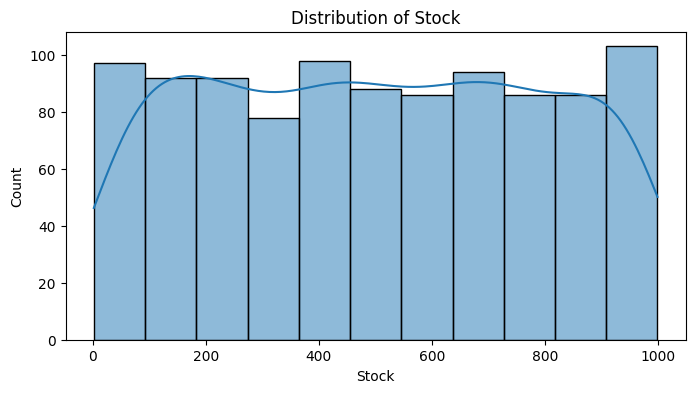

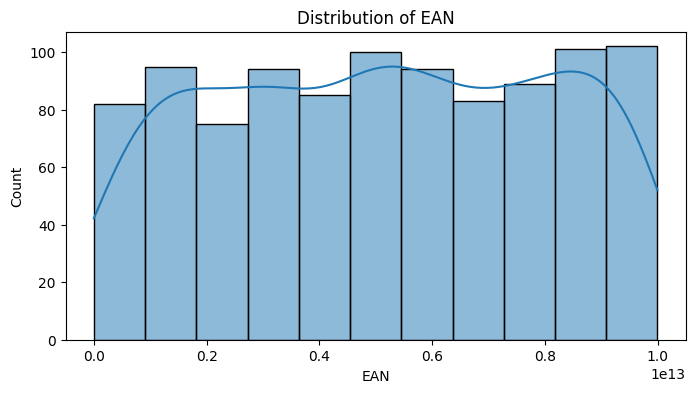

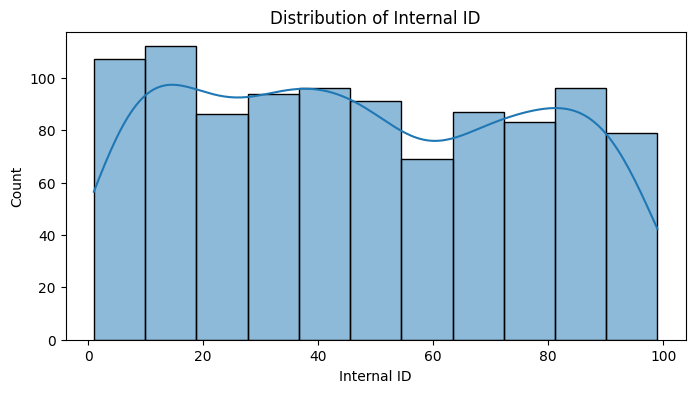

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**Observation:**
- **Price**: Near-uniform distribution across the range 1-999 USD. Mean and median are almost identical (~507), confirming the symmetric shape.
- **Stock**: Also near-uniform across 0-999 units. No heavy concentration at any particular inventory level.
- **Internal ID**: Ranges from 1-99 with a near-flat distribution. This is an internal reference number, not a predictive feature.
- **Index**: Perfectly uniform sequential identifier (1-1000). Should be excluded from ML feature matrices.
- **EAN**: Barcode identifier — uniformly spread. Not meaningful for arithmetic analysis.

All distributions are approximately symmetric with no visible right-skew or left-skew patterns.

## Box Plots (Outlier Detection)

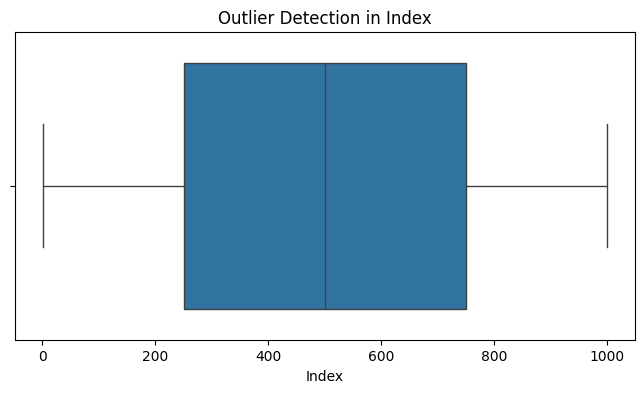

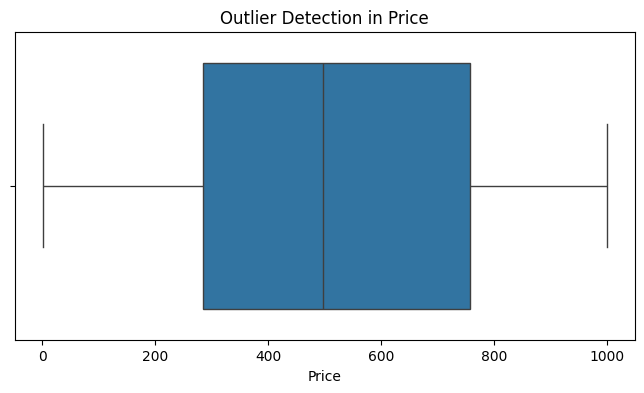

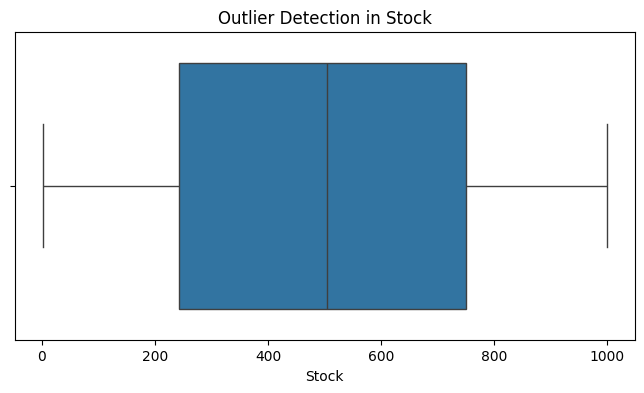

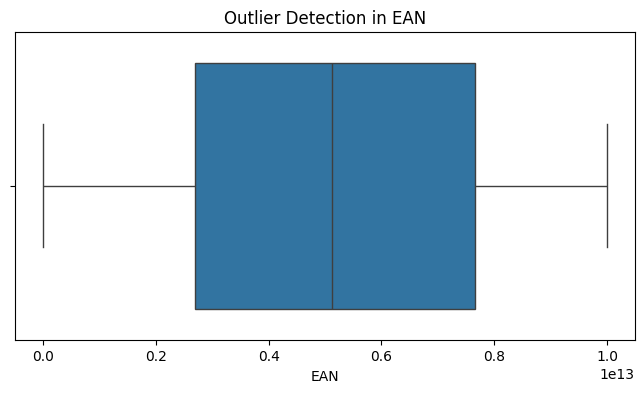

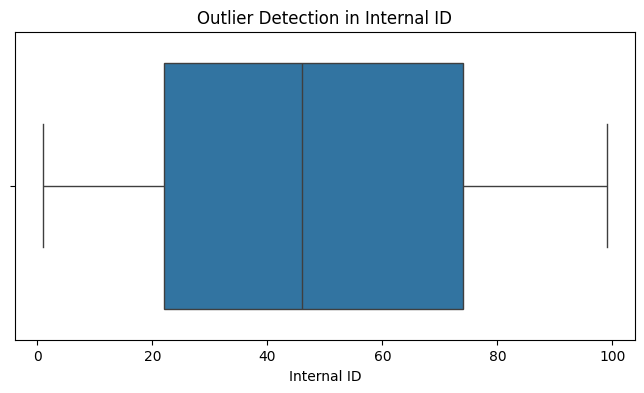

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection in {col}")
    plt.show()

**Observation:**
No extreme outliers detected in any numeric column using box plot whiskers (1.5 x IQR method). All values fall within the expected boundaries. This confirms the data is cleanly bounded:
- Price: 1 to 999
- Stock: 2 to 999
- Internal ID: 1 to 99

No capping, clipping, or winsorization is required.

## Bivariate Analysis: Price by Availability

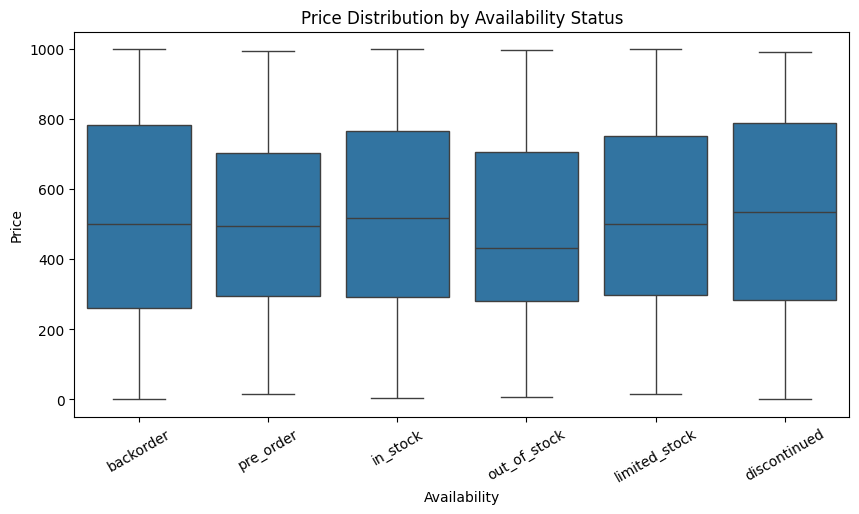

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Availability", y="Price")
plt.title("Price Distribution by Availability Status")
plt.xticks(rotation=30)
plt.show()

**Observation:**
Pricing is consistent across all availability statuses. Median prices hover around 500 USD for each group with similar IQR spreads. This suggests price is not a strong predictor of availability status.

## Correlation Heatmap

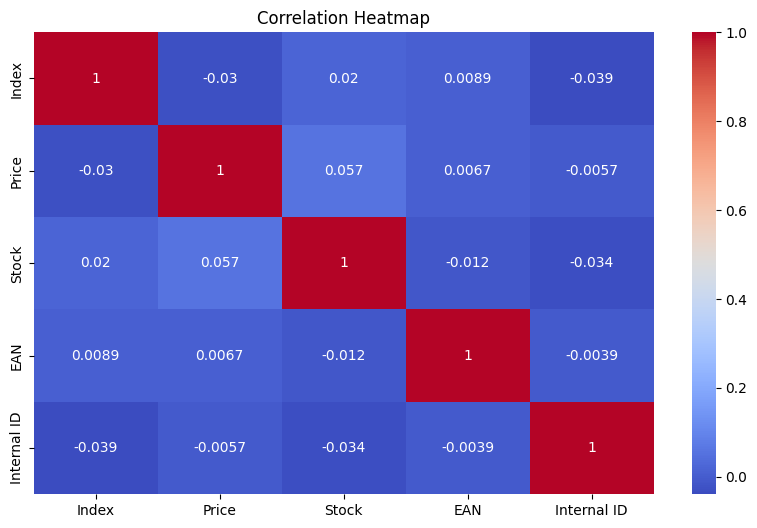

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:**
All pairwise Pearson correlations between numeric features are extremely weak (|r| < 0.06). There is no evidence of multicollinearity. Each feature captures independent information.

| Feature Pair | Correlation | Interpretation |
|-------------|-------------|----------------|
| Price vs Stock | +0.057 | Negligible |
| Price vs Internal ID | -0.006 | Near zero |
| Stock vs Internal ID | -0.034 | Near zero |

## Category Distribution

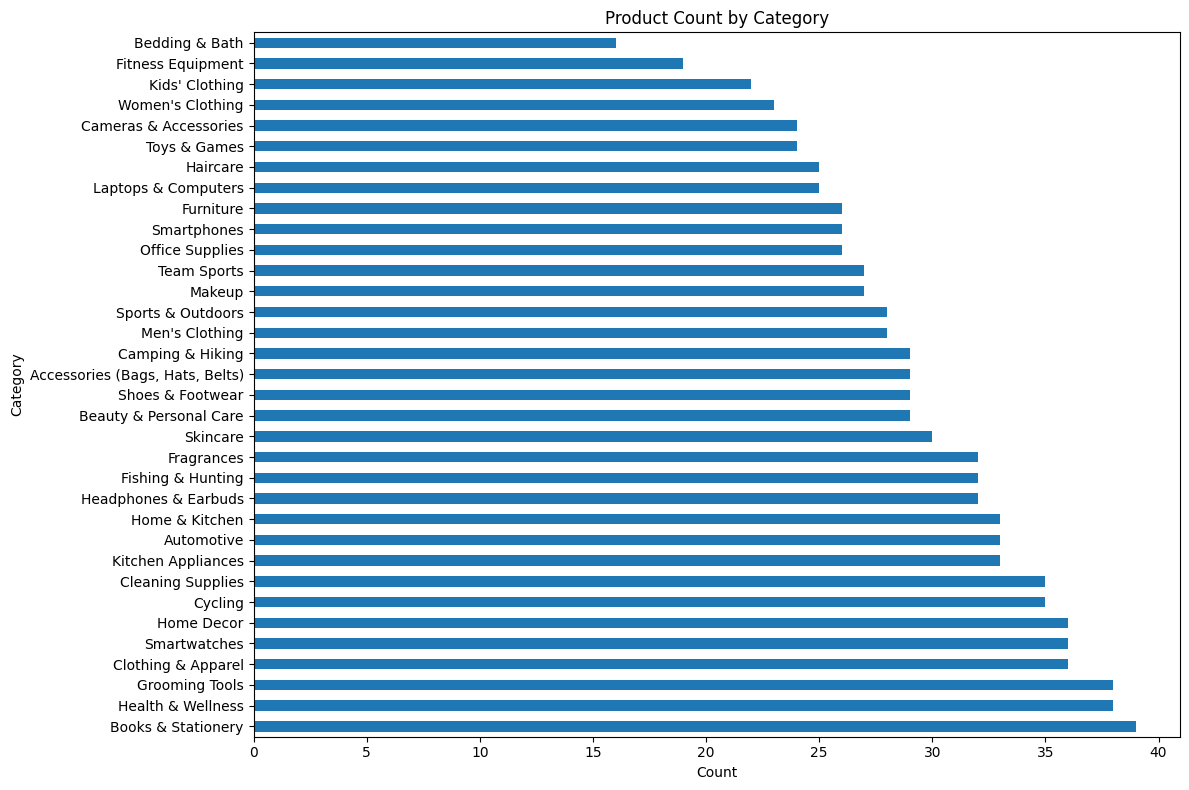

In [22]:
plt.figure(figsize=(12, 8))
df["Category"].value_counts().plot(kind="barh")
plt.title("Product Count by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Observation:**
The 34 categories are reasonably balanced. Books and Stationery (39), Health and Wellness (38), and Grooming Tools (38) lead slightly, but no category dominates excessively. No severe class imbalance issues for ML.

---

# Insights for ML Modeling

## 1. Highly Correlated Features
The correlation heatmap was used to identify features with strong positive or negative relationships. Highly correlated features may create multi-collinearity and data redundancy during model training.

**Result:** No high correlations were found between any numeric feature pairs (all |r| < 0.06). There is no risk of multicollinearity from the numeric features. However, the `Currency` column was a zero-variance feature (100% USD) and was removed to avoid redundancy.

## 2. Outlier Columns
Box plots were used to detect columns containing extreme outliers. These columns may require capping, clipping, log transformation, or scaling before training ML models.

**Result:** No statistical outliers were detected in any numeric column using the IQR method. All values fall within the 1.5 x IQR fence boundaries. No capping, clipping, or mathematical transformations are required.

## 3. Structural Changes Performed
The following cleaning steps were applied:
- Duplicate rows were removed.
- Corrupted numeric columns were converted using `pd.to_numeric(errors="coerce")`.
- Missing numeric values were filled using mean or median based on skewness.
- Missing categorical values were filled using mode.
- Zero-variance column (`Currency`) and filler text column (`Description`) were dropped.
- Final dataset was checked for null values and duplicate rows.

These steps ensure that the dataset can be safely passed into an ML algorithm's `.fit()` function without crashing due to bad inputs.

---
# Save Cleaned Dataset

In [23]:
df.to_csv("cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv saved successfully!")

cleaned_dataset.csv saved successfully!


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Index         1000 non-null   int64
 1   Name          1000 non-null   str  
 2   Brand         1000 non-null   str  
 3   Category      1000 non-null   str  
 4   Price         1000 non-null   int64
 5   Stock         1000 non-null   int64
 6   EAN           1000 non-null   int64
 7   Color         1000 non-null   str  
 8   Size          1000 non-null   str  
 9   Availability  1000 non-null   str  
 10  Internal ID   1000 non-null   int64
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [25]:
df.head()

,Index,Name,Brand,Category,Price,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Thermostat Drone Heater,Bradford-Yu,Kitchen Appliances,74,139,8619793560985,Orchid,Medium,backorder,38
1,2,Ultra Speaker Iron Grill Advanced One,Douglas Group,Fitness Equipment,510,351,3057216124300,MediumSeaGreen,Small,backorder,27
2,3,Watch Headphones Kettle,Landry-Austin,Beauty & Personal Care,254,409,9825254410556,Lavender,XXL,pre_order,2
3,4,Portable Toaster Clock Monitor Silent,"Odom, Norton and Foster",Makeup,69,119,9490814777808,Pink,XL,in_stock,94
4,5,Pro Toaster Oven,"Fowler, Mendoza and Mcdaniel",Automotive,525,727,4726650403799,LightCoral,XL,in_stock,95
